# Experiment Design and Monte Carlo Validation

## Objective

Before analyzing the experiment results, I estimated how many users would be needed to reliably detect a change in conversion rate.

For this calculation, I assumed:

- a baseline conversion rate based on the control group;
- a minimum detectable effect of **0.5 percentage points**;
- a two-sided significance level of **5%**;
- a target statistical power of **80%**;
- an equal split between the treatment and control groups.

The baseline conversion rate comes from the supplied dataset and is used here as an input for experiment planning. Since this is a retrospective analysis, the calculation does not imply that the original experiment was designed using this sample size.

I then use a Monte Carlo simulation to check whether the calculated sample size achieves approximately the expected statistical power.

> **Note on the effect size:**  
> The 0.5 percentage-point uplift is a scenario chosen for this project, not a universal business standard. At the observed baseline conversion rate, it represents a relatively large improvement. In a real-life experiment, the minimum detectable effect should be selected based on expected business value, implementation costs, and the amount of available traffic.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from scipy.stats import norm
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

ALPHA = 0.05
TARGET_POWER = 0.80
MDE_ABSOLUTE = 0.005  # this equals to 0.5 percentage points
N_SIMULATIONS = 10_000
SEED = 42


def find_project_root() -> Path:
    '''Find the repository root regardless of the notebook launch directory.'''
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "data" / "raw" / "marketing_AB.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate data/raw/marketing_AB.csv. Run the notebook inside the project repository."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "marketing_AB.csv"
VISUALS_DIR = PROJECT_ROOT / "visuals"
VISUALS_DIR.mkdir(exist_ok=True)

raw = pd.read_csv(DATA_PATH, usecols=["test group", "converted"])
BASELINE = raw.loc[raw["test group"].eq("psa"), "converted"].mean()
TARGET_RATE = BASELINE + MDE_ABSOLUTE
RELATIVE_MDE = MDE_ABSOLUTE / BASELINE

print(f"Control conversion rate: {BASELINE:.4%}")
print(f"Target conversion rate:  {TARGET_RATE:.4%}")
print(f"Absolute MDE:            {MDE_ABSOLUTE:.2%} ({MDE_ABSOLUTE * 100:.1f} pp)")
print(f"Relative uplift implied: {RELATIVE_MDE:.1%}")

Control conversion rate: 1.7854%
Target conversion rate:  2.2854%
Absolute MDE:            0.50% (0.5 pp)
Relative uplift implied: 28.0%


## 1. Closed-form sample-size calculation

For two independent proportions, `statsmodels` expresses the difference using Cohen's $h$:

$$h = 2\arcsin(\sqrt{p_1}) - 2\arcsin(\sqrt{p_0}).$$

The calculation below assumes a fixed-horizon test and a 1:1 allocation. Equal allocation is usually the most statistically efficient design when observation costs and variances are similar.

In [4]:
effect_size = proportion_effectsize(TARGET_RATE, BASELINE)
power_analysis = NormalIndPower()

required_n_per_group = int(
    np.ceil(
        power_analysis.solve_power(
            effect_size=effect_size,
            alpha=ALPHA,
            power=TARGET_POWER,
            ratio=1.0,
            alternative="two-sided",
        )
    )
)

sample_size_summary = pd.DataFrame(
    {
        "metric": [
            "Control rate",
            "Target rate",
            "Cohen's h",
            "Required users per group",
            "Required users in total",
        ],
        "value": [
            f"{BASELINE:.4%}",
            f"{TARGET_RATE:.4%}",
            f"{effect_size:.4f}",
            f"{required_n_per_group:,}",
            f"{2 * required_n_per_group:,}",
        ],
    }
)

sample_size_summary

,metric,value
0,Control rate,1.7854%
1,Target rate,2.2854%
2,Cohen's h,0.0355
3,Required users per group,"12,474"
4,Required users in total,"24,948"


## 2. Monte Carlo validation

The simulation draws conversion **counts** directly from binomial distributions. This is equivalent to simulating individual binary outcomes but is substantially faster and more memory-efficient.

The estimated power is the share of simulated experiments in which the two-sided pooled z-test rejects the null hypothesis at $\alpha=0.05$.

In [5]:
def simulate_two_proportion_power(
    p_control: float,
    p_treatment: float,
    n_control: int,
    n_treatment: int,
    n_simulations: int = 10_000,
    alpha: float = 0.05,
    seed: int = 42,
) -> tuple[float, tuple[float, float]]:
    '''Estimate power and a Monte Carlo uncertainty interval.'''
    rng = np.random.default_rng(seed)
    x_control = rng.binomial(n_control, p_control, size=n_simulations)
    x_treatment = rng.binomial(n_treatment, p_treatment, size=n_simulations)

    observed_control = x_control / n_control
    observed_treatment = x_treatment / n_treatment
    pooled = (x_control + x_treatment) / (n_control + n_treatment)
    standard_error = np.sqrt(
        pooled * (1 - pooled) * (1 / n_control + 1 / n_treatment)
    )

    z_statistics = np.divide(
        observed_treatment - observed_control,
        standard_error,
        out=np.zeros_like(standard_error, dtype=float),
        where=standard_error > 0,
    )
    p_values = 2 * norm.sf(np.abs(z_statistics))
    estimated_power = float(np.mean(p_values < alpha))

    mc_se = np.sqrt(estimated_power * (1 - estimated_power) / n_simulations)
    mc_interval = (
        max(0.0, estimated_power - 1.96 * mc_se),
        min(1.0, estimated_power + 1.96 * mc_se),
    )
    return estimated_power, mc_interval


simulated_power, simulated_power_ci = simulate_two_proportion_power(
    p_control=BASELINE,
    p_treatment=TARGET_RATE,
    n_control=required_n_per_group,
    n_treatment=required_n_per_group,
    n_simulations=N_SIMULATIONS,
    alpha=ALPHA,
    seed=SEED,
)

print(f"Target analytical power: {TARGET_POWER:.1%}")
print(f"Simulated power:         {simulated_power:.1%}")
print(
    "95% Monte Carlo uncertainty interval for simulated power: "
    f"[{simulated_power_ci[0]:.1%}, {simulated_power_ci[1]:.1%}]"
)

Target analytical power: 80.0%
Simulated power:         80.6%
95% Monte Carlo uncertainty interval for simulated power: [79.8%, 81.4%]


## 3. Power by sample size

The table below shows how statistical power changes as the number of users in each group increases.

I calculated power in two ways: analytically with `statsmodels` and through Monte Carlo simulation. The similar results provide a useful check that both approaches are consistent.

In [7]:
sample_sizes = sorted(
    {2_000, 5_000, 8_000, required_n_per_group, 16_000, 20_000}
)

power_rows = []
for index, n_per_group in enumerate(sample_sizes):
    analytical_power = power_analysis.power(
        effect_size=effect_size,
        nobs1=n_per_group,
        alpha=ALPHA,
        ratio=1.0,
        alternative="two-sided",
    )
    monte_carlo_power, _ = simulate_two_proportion_power(
        p_control=BASELINE,
        p_treatment=TARGET_RATE,
        n_control=n_per_group,
        n_treatment=n_per_group,
        n_simulations=5_000,
        alpha=ALPHA,
        seed=SEED + index,
    )
    power_rows.append(
        {
            "n_per_group": n_per_group,
            "analytical_power": analytical_power,
            "simulated_power": monte_carlo_power,
        }
    )

power_curve = pd.DataFrame(power_rows)
power_curve

,n_per_group,analytical_power,simulated_power
0,2000,0.202003,0.1906
1,5000,0.426232,0.4332
2,8000,0.611682,0.6150
3,12474,0.800012,0.8022
4,16000,0.887438,0.8938
5,20000,0.943804,0.9406


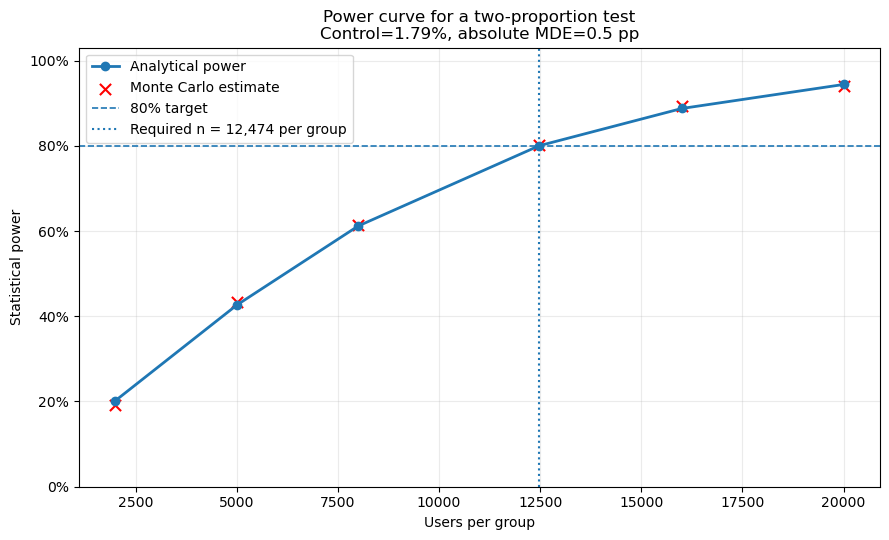

Saved: visuals\power_curve.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(
    power_curve["n_per_group"],
    power_curve["analytical_power"],
    marker="o",
    linewidth=2,
    label="Analytical power",
)

ax.scatter(
    power_curve["n_per_group"],
    power_curve["simulated_power"],
    marker="x",
    s=65,
    color="red",
    label="Monte Carlo estimate",
)

ax.axhline(
    TARGET_POWER,
    linestyle="--",
    linewidth=1.2,
    label="80% target",
)

ax.axvline(
    required_n_per_group,
    linestyle=":",
    linewidth=1.5,
    label=f"Required n = {required_n_per_group:,} per group",
)

ax.set_xlabel("Users per group")
ax.set_ylabel("Statistical power")
ax.set_title(
    "Power curve for a two-proportion test\n"
    f"Control={BASELINE:.2%}, absolute MDE={MDE_ABSOLUTE * 100:.1f} pp"
)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1.03)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()

output_path = VISUALS_DIR / "power_curve.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved: {output_path.relative_to(PROJECT_ROOT)}")

- The Monte Carlo estimates closely follow the analytical power curve, providing a useful implementation check for the sample-size calculation.

## 4. Avoiding early stopping

This calculation assumes that the experiment runs until the planned sample size is reached.

Checking the p-value repeatedly and stopping as soon as it falls below 0.05 increases the risk of a false-positive result. If results need to be monitored during the experiment, the interim checks and stopping rules should be planned in advance using an appropriate sequential-testing method.

## Design conclusion

Under the assumptions used in this notebook, the experiment would require approximately **12.5k users per group** to detect a 0.5 percentage-point uplift with 80% power.

The Monte Carlo results are close to the analytical estimates, suggesting that the calculation has been implemented consistently. This is a planning exercise based on historical data and does not imply that the original experiment was designed with this sample size.